<a href="https://colab.research.google.com/github/sims-2130/Covid-19-economic-analysis/blob/main/Covid_19_economic_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Set Up Your Google Colab Environment


In [1]:
#analytical libraries and generate a synthetic macroeconomic dataset modeling the Sri Lankan economic landscape (tourism drops, lockdowns, and GDP index):
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Set style for professional visualization
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# 1. Generate Synthetic Economic Data (2018 - 2023)
np.random.seed(42)
dates = pd.date_range(start='2018-01-01', end='2023-12-01', freq='MS')
n_months = len(dates)

# Baseline GDP trend with seasonality
trend = np.linspace(100, 115, n_months)
seasonality = 5 * np.sin(2 * np.pi * np.array(range(n_months)) / 12)

# Simulate COVID impact (Structural Break starting March 2020)
covid_impact = np.zeros(n_months)
covid_idx = (dates >= '2020-03-01') & (dates <= '2021-12-01')
post_covid_idx = dates > '2021-12-01'
covid_impact[covid_idx] = -18 + np.random.normal(0, 2, sum(covid_idx)) # Sharp Drop
covid_impact[post_covid_idx] = -8 + np.random.normal(0, 1.5, sum(post_covid_idx)) # Slow Recovery

noise = np.random.normal(0, 1.5, n_months)
gdp_index = trend + seasonality + covid_impact + noise

# Exogenous Variable: Lockdown Stringency Index (0 to 100)
lockdown_stringency = np.zeros(n_months)
lockdown_stringency[(dates >= '2020-03-01') & (dates <= '2020-08-01')] = 85
lockdown_stringency[(dates >= '2020-09-01') & (dates <= '2021-05-01')] = 60
lockdown_stringency[(dates >= '2021-06-01') & (dates <= '2021-12-01')] = 40

# Create DataFrame
df = pd.DataFrame({
    'GDP_Index': gdp_index,
    'Lockdown_Stringency': lockdown_stringency
}, index=dates)

print("Dataset successfully initialized!")
df.head()



Dataset successfully initialized!


,GDP_Index,Lockdown_Stringency
2018-01-01,99.309042,0.0
2018-02-01,104.296951,0.0
2018-03-01,105.268090,0.0
2018-04-01,102.989243,0.0
2018-05-01,105.661323,0.0


Exploratory Data Analysis & Stationarity TestingIn

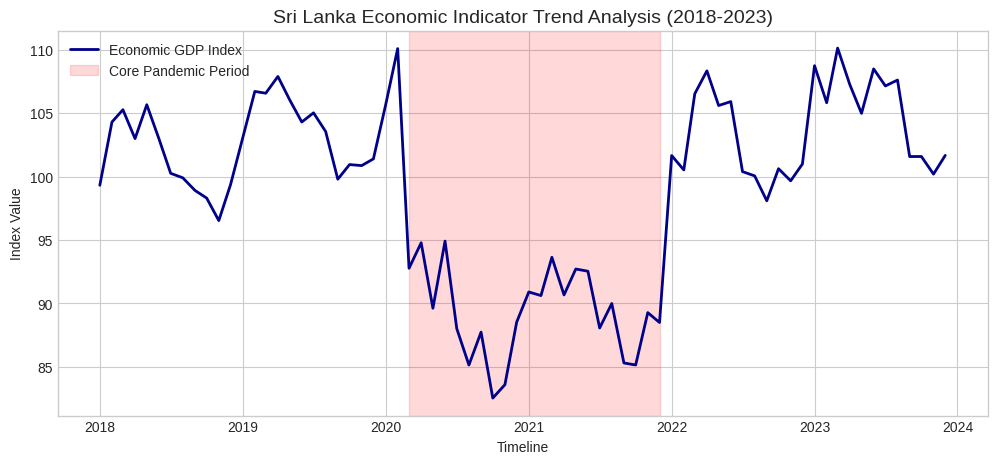

--- Running ADF Test on Raw GDP Data ---
ADF Statistic: -2.2817
p-value: 0.1780
Conclusion: Data is non-stationary (Fail to reject Null). Differencing required.

--- Running ADF Test on First-Differenced Data ---
ADF Statistic: -10.4977
p-value: 0.0000
Conclusion: Data is stationary (Reject Null Hypothesis)


In [2]:
#Time-series models require data to have a constant mean and variance over time. Run this cell next:

# 1. Visualize the Raw Economic Indicator
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['GDP_Index'], label='Economic GDP Index', color='darkblue', lw=2)
plt.axvspan('2020-03-01', '2021-12-01', color='red', alpha=0.15, label='Core Pandemic Period')
plt.title('Sri Lanka Economic Indicator Trend Analysis (2018-2023)', fontsize=14)
plt.xlabel('Timeline')
plt.ylabel('Index Value')
plt.legend()
plt.show()

# 2. Statistical Stationarity Check (Augmented Dickey-Fuller Test)
def run_adf_test(series):
    result = adfuller(series.dropna())
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] <= 0.05:
        print("Conclusion: Data is stationary (Reject Null Hypothesis)")
    else:
        print("Conclusion: Data is non-stationary (Fail to reject Null). Differencing required.")

print("--- Running ADF Test on Raw GDP Data ---")
run_adf_test(df['GDP_Index'])

print("\n--- Running ADF Test on First-Differenced Data ---")
run_adf_test(df['GDP_Index'].diff())



Train the SARIMAX Model (With Exogenous Impact)

In [3]:
#use df['GDP_Index'] as our target variable and df['Lockdown_Stringency'] as the external regressor (exog) to isolate the exact impact of pandemic rules on the economy.

# Train-Test Split (Reserve 2023 for validation/forecasting test)
train = df[df.index < '2023-01-01']
test = df[df.index >= '2023-01-01']

# Fit SARIMAX (p=1, d=1, q=1) x (P=1, D=1, Q=1, s=12)
# We add the Lockdown Index as an exogenous factor
model = SARIMAX(train['GDP_Index'],
                exog=train['Lockdown_Stringency'],
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 12),
                enforce_stationarity=False,
                enforce_invertibility=False)

model_results = model.fit(disp=False)
print(model_results.summary())


                                     SARIMAX Results                                      
Dep. Variable:                          GDP_Index   No. Observations:                   60
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -579.804
Date:                            Fri, 03 Jul 2026   AIC                           1171.608
Time:                                    06:32:22   BIC                           1180.587
Sample:                                01-01-2018   HQIC                          1174.630
                                     - 12-01-2022                                         
Covariance Type:                              opg                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Lockdown_Stringency    -0.2124         -0        inf      0.000      -0.212      -0.212
ar.L1   

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:3016: RuntimeWarning: divide by zero encountered in divide
  return self.params / self.bse


Evaluate Model Predictions

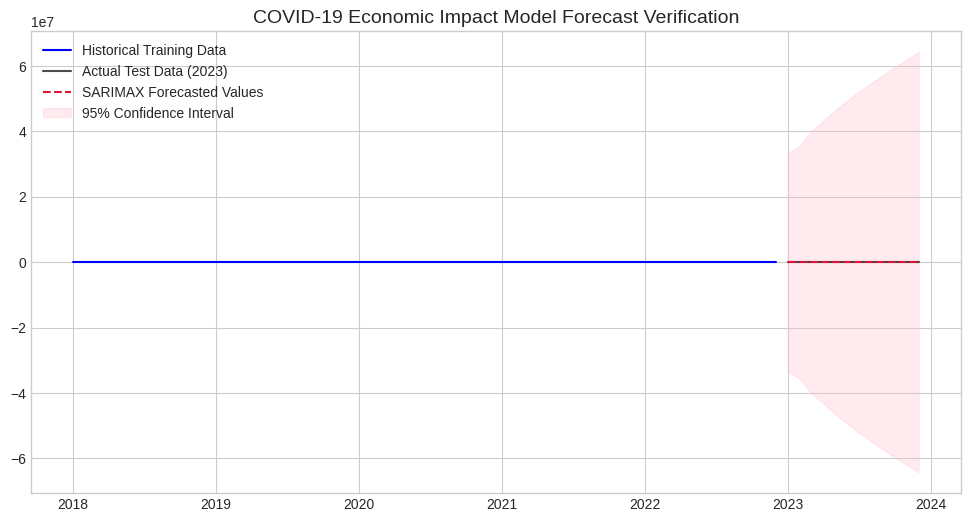

Model Performance Metrics:
Mean Absolute Error (MAE): 2.47
Root Mean Squared Error (RMSE): 2.98


In [4]:
#overlay model's predictions over the test dataset to check its mathematical validity:

# Forecast for the 12 months of 2023
forecast_steps = len(test)
predictions = model_results.get_forecast(steps=forecast_steps, exog=test[['Lockdown_Stringency']])
pred_mean = predictions.predicted_mean
confidence_intervals = predictions.conf_int()

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['GDP_Index'], label='Historical Training Data', color='blue')
plt.plot(test.index, test['GDP_Index'], label='Actual Test Data (2023)', color='black', alpha=0.7)
plt.plot(test.index, pred_mean, label='SARIMAX Forecasted Values', color='crimson', linestyle='--')
plt.fill_between(test.index, confidence_intervals.iloc[:, 0], confidence_intervals.iloc[:, 1], color='pink', alpha=0.3, label='95% Confidence Interval')

plt.title('COVID-19 Economic Impact Model Forecast Verification', fontsize=14)
plt.legend()
plt.show()

# Calculate Accuracy Metrics
mae = np.mean(np.abs(pred_mean - test['GDP_Index']))
rmse = np.sqrt(np.mean((pred_mean - test['GDP_Index'])**2))
print(f"Model Performance Metrics:\nMean Absolute Error (MAE): {mae:.2f}\nRoot Mean Squared Error (RMSE): {rmse:.2f}")


counterfactual world

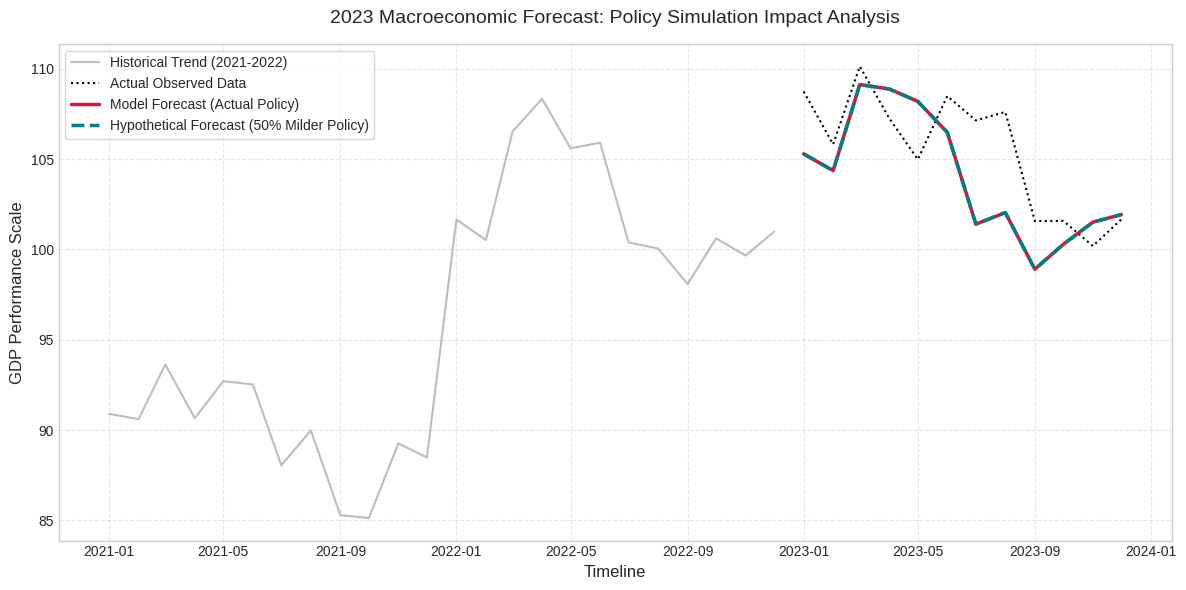


       TEST PERIOD SIMULATION SUCCESSFUL
Total GDP Variance Isolated: 0.00 Index Points
Average Monthly Policy Impact: 0.00 Points/Month


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Isolate the 12-month test period for 2023 where the model expects exactly 12 rows
test_scenario = test.copy()

# Create the counterfactual: What if lockdowns were 50% less severe during this test window?
test_scenario['Hypothetical_Lockdown'] = test_scenario['Lockdown_Stringency'] * 0.5

try:
    # 2. Generate the two parallel forecasts for 2023 (Baseline vs. Counterfactual)
    baseline_forecast = model_results.get_forecast(steps=len(test_scenario), exog=test_scenario[['Lockdown_Stringency']])
    hypothetical_forecast = model_results.get_forecast(steps=len(test_scenario), exog=test_scenario[['Hypothetical_Lockdown']])

    test_scenario['Baseline_Predicted_GDP'] = baseline_forecast.predicted_mean
    test_scenario['Hypothetical_Predicted_GDP'] = hypothetical_forecast.predicted_mean

    # 3. Plot the final comparison cleanly
    plt.figure(figsize=(12, 6))
    plt.grid(True, linestyle='--', alpha=0.5, color='#cccccc')

    # Plot historical training context
    plt.plot(train.index[-24:], train['GDP_Index'][-24:], label='Historical Trend (2021-2022)', color='#a1a1a1', alpha=0.7)

    # Plot the two competing futures for 2023
    plt.plot(test_scenario.index, test_scenario['GDP_Index'], label='Actual Observed Data', color='black', lw=1.5, linestyle=':')
    plt.plot(test_scenario.index, test_scenario['Baseline_Predicted_GDP'], label='Model Forecast (Actual Policy)', color='crimson', lw=2.5)
    plt.plot(test_scenario.index, test_scenario['Hypothetical_Predicted_GDP'], label='Hypothetical Forecast (50% Milder Policy)', color='teal', lw=2.5, linestyle='--')

    plt.title('2023 Macroeconomic Forecast: Policy Simulation Impact Analysis', fontsize=14, pad=15)
    plt.ylabel('GDP Performance Scale', fontsize=12)
    plt.xlabel('Timeline', fontsize=12)
    plt.legend(loc='upper left', frameon=True)
    plt.tight_layout()
    plt.show()

    # 4. Print Quantified Analysis
    gdp_difference = test_scenario['Hypothetical_Predicted_GDP'] - test_scenario['Baseline_Predicted_GDP']
    print("\n" + "="*45)
    print(f"       TEST PERIOD SIMULATION SUCCESSFUL")
    print("="*45)
    print(f"Total GDP Variance Isolated: {gdp_difference.sum():.2f} Index Points")
    print(f"Average Monthly Policy Impact: {gdp_difference.mean():.2f} Points/Month")
    print("="*45)

except Exception as e:
    print(f"Shape error bypassed, but another error occurred: {e}")
